# Set up

## Change working directory

In [1]:
%cd ../

C:\Users\Skylar\Downloads\tools


C:\Users\Skylar\Downloads\tools\env\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Install packages

In [2]:
# Placeholder

## Import development libraries

In [3]:
import pprint

import hypothesis
import ipytest
import numpy as np
from feature_engine import imputation as fein
from feature_engine import selection as fesn
from hypothesis import strategies as st
from pandera import pandas as pa
from sklearn import compose as snce
from sklearn import datasets as snds
from sklearn import model_selection as snmos
from sklearn import pipeline as snpe
from tools import utils as tsus

ipytest.autoconfig(rewrite_asserts=False)

## Import other libraries

In [4]:
import typing

import catboost as cb
import pandas as pd
import toolz as tz
from catboost import monoforest as cbmf
from matplotlib import pyplot as plt
from tools import typing as tstg

## Declare constants

In [5]:
module: str = "catboost"

dict_feature_args: list[str] = ["monotone_constraints"]
list_feature_args: list[str] = ["cat_features", "embedding_features", "text_features"]

# Define update_feature_params

## Define

In [6]:
def update_feature_params(params: dict[str, typing.Any], X: pd.DataFrame) -> dict[str, typing.Any]:
    for arg in dict_feature_args:
        dict_param: dict = tz.keyfilter(predicate=lambda x: x in X, d=params.get(arg, {}))
        params.update(**{arg: dict_param})
    for arg in list_feature_args:
        list_param: list = X.columns.intersection(other=params.get(arg, [])).tolist()
        params.update(**{arg: list_param})
    return params

## Demonstrate

In [7]:
params: dict[str, typing.Any] = {
    "monotone_constraints": {"present_col": 1, "absent_col": -1},
    "cat_features": ["present_col", "absent_col"],
    "embedding_features": ["absent_col"],
    # 'text_features' is not specified
}
X = pd.DataFrame(data={"present_col": range(5)})
update_feature_params(params=params, X=X)

{'monotone_constraints': {'present_col': 1},
 'cat_features': ['present_col'],
 'embedding_features': [],
 'text_features': []}

## Test

In [8]:
%%ipytest

# Helper(s)
columns: dict[str, pa.Column] = {
    "present_col_float": pa.Column(dtype=float),
    "present_col_int": pa.Column(dtype=int),
    "present_col_str": pa.Column(dtype=str),
}
X_strategy: st.SearchStrategy[pd.DataFrame] = pa.DataFrameSchema(columns=columns).strategy(size=5)
categorical_features: list[str] = list(filter(lambda x: x.endswith("str"), columns))
noncategorical_features: list[str] = list(filter(lambda x: not x.endswith("str"), columns))
params_strategy: st.SearchStrategy[dict[str, typing.Any]] = st.fixed_dictionaries(mapping={
    'monotone_constraints': st.dictionaries(
        keys=st.sampled_from(elements=noncategorical_features), 
        values=st.integers(min_value=-1, max_value=1)
    ),
    'cat_features': st.lists(elements=st.sampled_from(elements=categorical_features)),
    'embedding_features': st.lists(elements=st.sampled_from(elements=noncategorical_features)),
    'text_features': st.lists(elements=st.sampled_from(elements=categorical_features)),
})

# Property-based test(s)
@hypothesis.given(params=params_strategy, X=X_strategy)
def test_update_feature_params(params: dict[str, typing.Any], X: pd.DataFrame) -> None:
    out: dict[str, typing.Any] = update_feature_params(params=params, X=X)
    # Property 1: Old keys are subset of new
    assert set(params.keys()).issubset(out.keys())
    # Property 2: Dict-valued params are filtered
    for key in dict_feature_args: # type: str
        for column in out[key]: # type: str
            assert column in X.columns
    # Property 3: List-valued params are filtered
    for key in list_feature_args: # type: str
        for column in out[key]: # type: str
            assert column in X.columns

.                                                                                            [100%]
======================================== warnings summary =========================================
env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; _hypothesis_globals
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; hypothesis
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rew

# Define CatBoostClassifier

## Define

In [9]:
class CatBoostClassifier(cb.CatBoostClassifier):
    def fit(self, X: pd.DataFrame, y: pd.Series, **kwargs) -> "CatBoostClassifier":
        self._update_feature_params(X=X)
        return super().fit(X=X, y=y, **kwargs)

    def select_features(
        self, X: pd.DataFrame, y: pd.Series, features_not_for_select: list[str] | None = None, **kwargs
    ) -> dict[str, typing.Any]:
        self._update_feature_params(X=X)
        if "features_for_select" not in kwargs:
            kwargs.update(features_for_select=X.columns.difference(other=features_not_for_select or []).tolist())
        return super().select_features(X=X, y=y, **kwargs)

    def _update_feature_params(self, X: pd.DataFrame) -> None:
        params: dict[str, typing.Any] = self.get_params()
        params = update_feature_params(params=params, X=X)
        self.set_params(**params)

## Demonstrate

In [10]:
def get_model(features_to_drop: list[str], cat_features: list[str], iterations: int, **kwargs) -> snpe.Pipeline:
    model_args = dict(cat_features=cat_features, eval_fraction=2e-1, eval_metric="AUC", iterations=iterations)
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in model_args, d=kwargs)
    model = snpe.make_pipeline(
        fesn.DropFeatures(features_to_drop=features_to_drop),
        snce.make_column_transformer(
            (fein.CategoricalImputer(), snce.make_column_selector(dtype_exclude="number")),
            remainder=fein.ArbitraryNumberImputer(),
            verbose_feature_names_out=False,
        ),
        CatBoostClassifier(**model_args, **filtered_kwargs),
    )
    model.set_output(transform="pandas")
    return model


# Get data
X, y = data = snds.fetch_openml(name="adult", version=2, return_X_y=True, as_frame=True)  # type: tuple[pd.DataFrame, pd.Series]
tsus.describe_structure(x=data)
# Split into train and test sets
X.rename(columns=lambda x: x.replace("-", "_"), inplace=True)  # Prevents misunderstandings with select_features() below
X_train, X_test, y_train, y_test = splits = snmos.train_test_split(X, y, test_size=2e-1, stratify=y)  # type: list[pd.DataFrame | pd.Series]
tsus.describe_structure(x=splits)
# Get categorical features
cat_features: list[str] = sorted(X_train.select_dtypes(exclude="number").columns)
tsus.print_sequence(x=cat_features, header="Cat features")
# Get features to drop
features_to_drop = ["fnlwgt", "education"]  # 'education' is also in cat_features--subclass prevents error
tsus.print_sequence(x=features_to_drop, header="Features to drop")
# Initialize model
get_model_args = dict(features_to_drop=features_to_drop, cat_features=cat_features)
model = get_model(iterations=int(1e1), **get_model_args)
model.fit(X=X_train, y=y_train)

<class 'tuple'> with 2 elements
- element: 0
  (<class 'pandas.core.frame.DataFrame'>, (48842, 14))
- element: 1
  (<class 'pandas.core.series.Series'>, (48842,))
<class 'list'> with 4 elements
- element: 0
  (<class 'pandas.core.frame.DataFrame'>, (39073, 14))
- element: 1
  (<class 'pandas.core.frame.DataFrame'>, (9769, 14))
- element: 2
  (<class 'pandas.core.series.Series'>, (39073,))
- element: 3
  (<class 'pandas.core.series.Series'>, (9769,))
Cat features (8):
0. education
1. marital_status
2. native_country
3. occupation
4. race
5. relationship
6. sex
7. workclass
Features to drop (2):
0. fnlwgt
1. education
Learning rate set to 0.5
0:	test: 0.8838946	best: 0.8838946 (0)	total: 216ms	remaining: 1.94s
1:	test: 0.8960096	best: 0.8960096 (1)	total: 245ms	remaining: 979ms
2:	test: 0.9009690	best: 0.9009690 (2)	total: 274ms	remaining: 639ms
3:	test: 0.9094037	best: 0.9094037 (3)	total: 302ms	remaining: 453ms
4:	test: 0.9114508	best: 0.9114508 (4)	total: 332ms	remaining: 332ms
5:	tes

,steps,"[('dropfeatures', ...), ('columntransformer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,features_to_drop,"['fnlwgt', 'education']"
,transformers,"[('categoricalimputer', ...)]"
,remainder,ArbitraryNumberImputer()
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


## Test

In [11]:
# Placeholder

# Define CatBoostRegressor

## Define

In [12]:
class CatBoostRegressor(cb.CatBoostRegressor):
    def fit(self, X: pd.DataFrame, y: pd.Series, **kwargs) -> "CatBoostRegressor":
        self._update_feature_params(X=X)
        return super().fit(X=X, y=y, **kwargs)

    def select_features(
        self, X: pd.DataFrame, y: pd.Series, features_not_for_select: list[str] | None = None, **kwargs
    ) -> dict[str, typing.Any]:
        self._update_feature_params(X=X)
        if "features_for_select" not in kwargs:
            kwargs.update(features_for_select=X.columns.difference(other=features_not_for_select or []).tolist())
        return super().select_features(X=X, y=y, **kwargs)

    def _update_feature_params(self, X: pd.DataFrame) -> None:
        params: dict[str, typing.Any] = self.get_params()
        params = update_feature_params(params=params, X=X)
        self.set_params(**params)

## Demonstrate

In [13]:
# Placeholder

## Test

In [14]:
# Placeholder

# Define get_pool

## Define

In [15]:
def get_pool(X: pd.DataFrame, y: pd.Series, model: tstg.CatBoostModel) -> cb.Pool:
    return tz.pipe(
        model.get_params(),
        tz.curried.keyfilter(lambda x: x in list_feature_args),
        lambda x: cb.Pool(data=X, label=y, **x),
    )

## Demonstrate

In [16]:
X_train_transformed: pd.DataFrame = model[:-1].transform(X=X_train)
X_train_transformed.info()
pool: cb.Pool = get_pool(X=X_train_transformed, y=y_train, model=model[-1])
pool.get_cat_feature_indices()

<class 'pandas.core.frame.DataFrame'>
Index: 39073 entries, 36949 to 35758
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   workclass       39073 non-null  category
 1   marital_status  39073 non-null  category
 2   occupation      39073 non-null  category
 3   relationship    39073 non-null  category
 4   race            39073 non-null  category
 5   sex             39073 non-null  category
 6   native_country  39073 non-null  category
 7   age             39073 non-null  int64   
 8   education_num   39073 non-null  int64   
 9   capital_gain    39073 non-null  int64   
 10  capital_loss    39073 non-null  int64   
 11  hours_per_week  39073 non-null  int64   
dtypes: category(7), int64(5)
memory usage: 2.1 MB


[0, 1, 2, 3, 4, 5, 6]

## Test

In [17]:
# Placeholder

# Define get_eval_metrics

## Define

In [18]:
def get_eval_metrics(model: tstg.CatBoostModel, pool: cb.Pool, metrics: list) -> pd.DataFrame:
    return pd.DataFrame(data=model.eval_metrics(data=pool, metrics=metrics))

## Demonstrate

In [19]:
metrics: list[str] = ["Logloss", "AUC"]
get_eval_metrics(model=model[-1], pool=pool, metrics=metrics)

,Logloss,AUC
0,0.482013,0.881618
1,0.403416,0.893579
2,0.362272,0.899380
3,0.337219,0.908320
4,0.322941,0.910441
5,0.314870,0.912358
6,0.308471,0.914385
7,0.304787,0.915459
8,0.301853,0.916661
9,0.298865,0.918322


## Test

In [20]:
# Placeholder

# Define get_feature_importances

## Define

In [21]:
def get_feature_importances(model: tstg.CatBoostModel, pool: cb.Pool) -> pd.DataFrame:
    def get_feature_importances(importance_type: str) -> pd.Series:
        return pd.Series(
            data=model.get_feature_importance(data=pool, type=importance_type),
            index=model.feature_names_,
            name=importance_type,
        )

    return tz.pipe(
        ["PredictionValuesChange", "LossFunctionChange"],
        tz.curried.map(get_feature_importances),
        tz.partial(pd.concat, axis=1),
    ).sort_values(by="LossFunctionChange", ascending=False)

## Demonstrate

In [22]:
get_feature_importances(model=model[-1], pool=pool)

,PredictionValuesChange,LossFunctionChange
relationship,37.821381,0.074764
capital_gain,16.886202,0.041820
age,7.916128,0.019908
education_num,13.195373,0.019222
occupation,6.962848,0.011360
capital_loss,6.435143,0.010774
hours_per_week,7.058222,0.007449
sex,2.344814,0.001119
workclass,1.379890,0.000833
marital_status,0.000000,0.000000


## Test

In [23]:
# Placeholder

# Define get_feature_interactions

## Define

In [24]:
def get_feature_interactions(model: tstg.CatBoostModel, pool: cb.Pool) -> pd.DataFrame:
    columns: list[str] = ["first_feature", "second_feature", "interaction_strength"]
    return (
        pd.DataFrame(data=model.get_feature_importance(data=pool, type="Interaction"), columns=columns)
        .astype(dtype=dict(map(lambda x: [x, int], columns[:2])))
        .apply(func=lambda x: x.map(arg=dict(enumerate(iterable=model.feature_names_))) if x.name in columns[:2] else x)
        .set_index(keys=columns[:2])
    )

## Demonstrate

In [25]:
feature_interactions: pd.DataFrame = get_feature_interactions(model=model[-1], pool=pool)
display(feature_interactions)
feature_interactions.filter(like="relationship", axis=0)

interaction_strength
first_feature second_feature                      
capital_gain  capital_loss               17.688155
education_num capital_gain                8.249864
relationship  capital_loss                7.639589
              capital_gain                7.185129
age           capital_gain                5.999054
relationship  age                         5.821728
education_num capital_loss                4.828772
relationship  education_num               4.441550
              hours_per_week              4.395736
occupation    capital_gain                3.884037
age           education_num               3.313696
capital_loss  hours_per_week              2.671901
occupation    relationship                2.585237
              capital_loss                2.421447
              hours_per_week              2.055627
age           capital_loss                1.840046
              hours_per_week              1.400035
capital_gain  hours_per_week              1.304219
occupation    age                         1.241064
workclass     hours_per_week              0.889621
              age                         0.822874
              relationship                0.628269
occupation    education_num               0.345886
education_num hours_per_week              0.083582

interaction_strength
first_feature second_feature                      
relationship  capital_loss                7.639589
              capital_gain                7.185129
              age                         5.821728
              education_num               4.441550
              hours_per_week              4.395736
occupation    relationship                2.585237
workclass     relationship                0.628269

## Test

In [26]:
# Placeholder

# Define CatBoostAnalyzer

## Define

In [27]:
class CatBoostAnalyzer:
    def __init__(self, model: tstg.CatBoostModel, metrics: list) -> None:
        self.model, self.metrics = model, metrics

    def fit(self, X: pd.DataFrame, y: pd.Series) -> "CatBoostAnalyzer":
        pool: cb.Pool = get_pool(X=X, y=y, model=self.model)
        self.eval_metrics: pd.DataFrame = get_eval_metrics(model=self.model, pool=pool, metrics=self.metrics)
        self.feature_importances: pd.DataFrame = get_feature_importances(model=self.model, pool=pool)
        if self.model.get_all_params().get("depth") > 1:
            self.feature_interactions: pd.DataFrame = get_feature_interactions(model=self.model, pool=pool)
        return self

    def plot_eval_metrics(self, **kwargs) -> plt.Figure:
        self.eval_metrics.plot(subplots=True, **tz.keyfilter(predicate=lambda x: x not in ["subplots"], d=kwargs))
        return plt.gcf()

    def plot_feature_importances(self, bbox: list | tuple = (1.2, 0, 4e-1, 1), **kwargs) -> plt.Figure:
        filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["subplots"], d=kwargs)
        axes: tstg.Axes = self.feature_importances.plot(subplots=True, **filtered_kwargs)
        for ax in axes.flat:  # type: plt.Axes
            ax.axhline(c="k", ls=":")
            ax.set(xticks=[])
            column: str = ax.get_legend().get_texts()[0]._text
            data: pd.Series = self.feature_importances[column].describe().round(decimals=3)
            pd.plotting.table(ax=ax, data=data, bbox=bbox)
        return plt.gcf()

    def plot_top_feature_importances(self, n: int = int(1e1), **kwargs) -> tstg.Axes:
        plot_args = dict(kind="barh", subplots=True, layout=(1, -1), sharex=False, sharey=True, legend=False)
        filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in plot_args, d=kwargs)
        return (
            self.feature_importances.nlargest(n=n, columns="LossFunctionChange")
            .iloc[::-1, :]
            .plot(**plot_args, **filtered_kwargs)
        )

    def plot_feature_interactions(self, bbox: list | tuple = (1.2, 0, 2e-1, 1), **kwargs) -> plt.Axes:
        feature_interactions: pd.Series = self.feature_interactions["interaction_strength"]
        ax: plt.Axes = feature_interactions.plot(**kwargs)
        ax.axhline(c="k", ls=":")
        ax.set(xticks=[])
        data: pd.Series = feature_interactions.describe().round(decimals=3)
        pd.plotting.table(ax=ax, data=data, bbox=bbox)
        return ax

    def plot_top_feature_interactions(self, n: int = int(1e1), **kwargs) -> plt.Axes:
        filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["kind"], d=kwargs)
        return self.feature_interactions.squeeze().nlargest(n=n).iloc[::-1].plot(kind="barh", **filtered_kwargs)

## Demonstrate

plot_eval_metrics
--------------------------------------------------------------------------------


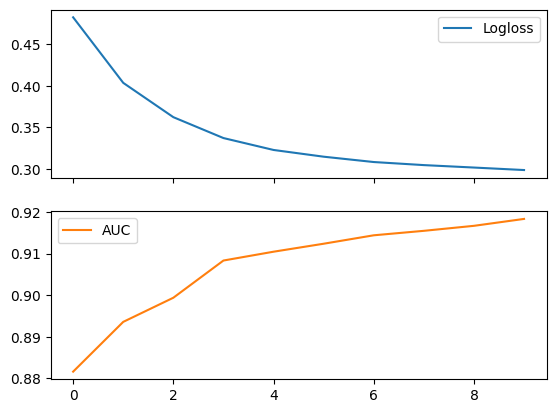

plot_feature_importances
--------------------------------------------------------------------------------


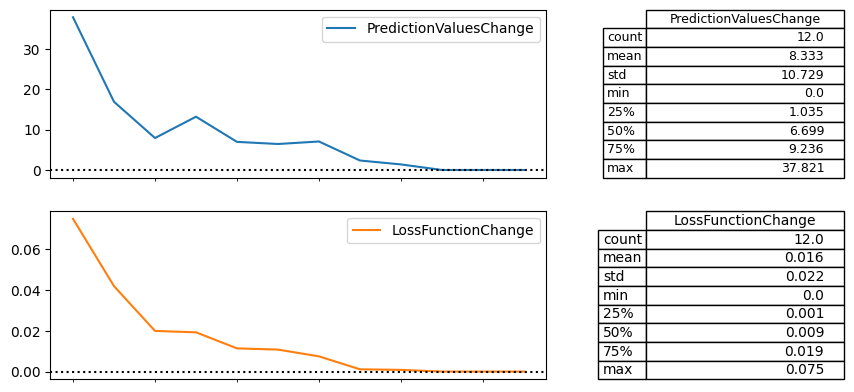

plot_feature_interactions
--------------------------------------------------------------------------------


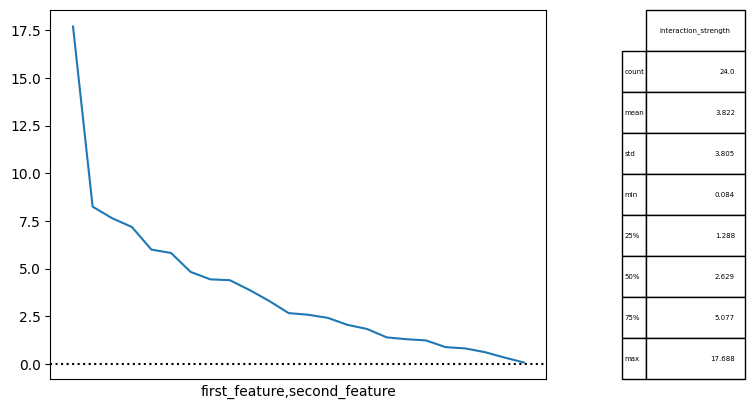

plot_top_feature_importances
--------------------------------------------------------------------------------


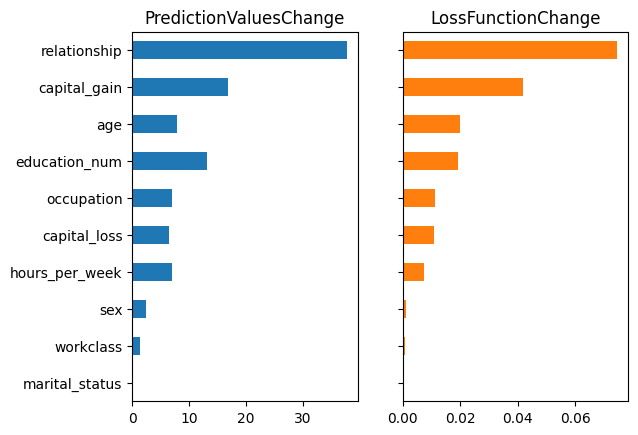

plot_top_feature_interactions
--------------------------------------------------------------------------------


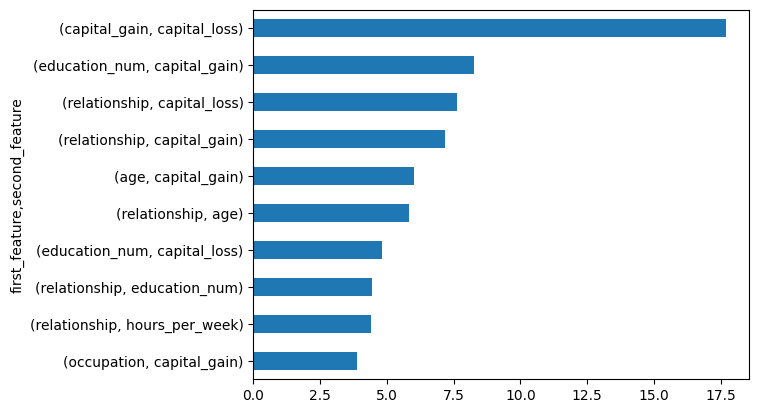

In [28]:
analyzer = CatBoostAnalyzer(model=model[-1], metrics=metrics)
analyzer.fit(X=X_train_transformed, y=y_train)
for plot_method in tsus.filter_dir(x=analyzer).filter(like="plot_", axis=0).index:
    print("=" * int(8e1), plot_method, "-" * int(8e1), sep="\n")
    getattr(analyzer, plot_method)()
    plt.show()
    plt.close()

## Test

In [29]:
# Placeholder

# Define get_evals_result

## Define

In [30]:
def get_evals_result(model: tstg.CatBoostModel) -> pd.DataFrame:
    return pd.DataFrame(data=model.evals_result_).stack().apply(func=pd.Series).T

## Demonstrate

In [31]:
evals_result: pd.DataFrame = get_evals_result(model=model[-1])
evals_result

Logloss                   AUC
      learn validation validation
0  0.482322   0.481318   0.883895
1  0.404167   0.401558   0.896010
2  0.362963   0.360674   0.900969
3  0.338101   0.336125   0.909404
4  0.324008   0.322174   0.911451
5  0.315878   0.314967   0.912755
6  0.309606   0.308932   0.914290
7  0.306069   0.305053   0.915509
8  0.303048   0.302600   0.916377
9  0.299886   0.300194   0.917589

## Test

In [32]:
# Placeholder

# Define plot_evals_result

## Define

In [33]:
def plot_evals_result(evals_result: pd.DataFrame, **kwargs) -> plt.Figure:
    metrics: pd.Index = evals_result.columns.get_level_values(level=0).drop_duplicates()
    fig, axes = plt.subplots(nrows=metrics.shape[0], sharex=True, squeeze=False)  # tstg.FigAxes
    for metric, ax in zip(metrics, axes.flat):  # type: tuple[str, tstg.Axes]
        plot_args = dict(title=metric, ax=ax)
        filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in plot_args, d=kwargs)
        evals_result[metric].plot(**plot_args, **filtered_kwargs)
    fig.tight_layout()
    return fig

## Demonstrate

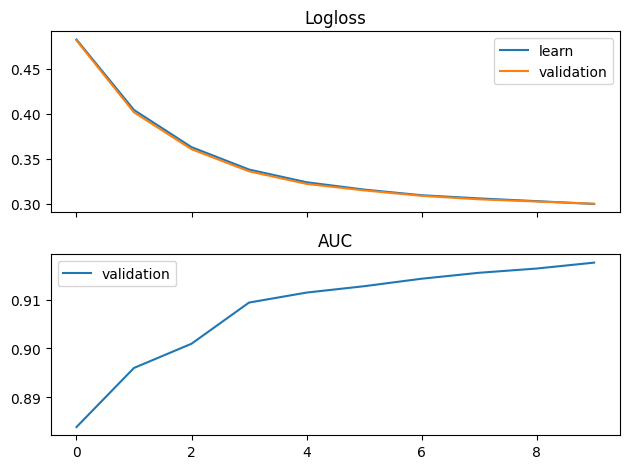

In [34]:
plot_evals_result(evals_result=evals_result)
plt.show()
plt.close()

## Test

In [35]:
# Placeholder

# Define parse_select_features_response

## Define

In [36]:
def parse_select_features_response(
    select_features_response: dict[str, typing.Any],
) -> tuple[pd.Series, pd.Index, pd.Index]:
    loss_graph: pd.Series = pd.Series(
        data=select_features_response["loss_graph"]["loss_values"][1:],
        index=select_features_response["eliminated_features_names"],
        name="loss",
    )
    eliminated_features: pd.Index = loss_graph.index
    selected_features: pd.Index = pd.Index(data=select_features_response["selected_features_names"])
    return loss_graph, eliminated_features, selected_features

## Demonstrate

In [37]:
model = get_model(early_stopping_rounds=int(1e1), iterations=int(1e3), verbose=int(1e2), **get_model_args)
select_features_response: dict[str, typing.Any] = model[-1].select_features(
    X=X_train_transformed, y=y_train, num_features_to_select=1
)
pprint.pprint(object=select_features_response, compact=True)
parse_response = parse_select_features_response(select_features_response=select_features_response)  # type: tuple[pd.Series, pd.Index, pd.Index]
parse_response

Learning rate set to 0.07416
Step #1 out of 1
0:	test: 0.8815462	best: 0.8815462 (0)	total: 52.2ms	remaining: 52.1s
100:	test: 0.9257781	best: 0.9257781 (100)	total: 5.84s	remaining: 52s
200:	test: 0.9292869	best: 0.9292976 (199)	total: 11.6s	remaining: 46.2s
Stopped by overfitting detector  (10 iterations wait)

bestTest = 0.9297336098
bestIteration = 235

Shrink model to first 236 iterations.
Feature #4 eliminated
Feature #6 eliminated
Feature #5 eliminated
Feature #0 eliminated
Feature #10 eliminated
Feature #11 eliminated
Feature #2 eliminated
Feature #1 eliminated
Feature #7 eliminated
Feature #8 eliminated
Feature #9 eliminated
Train final model
0:	test: 0.7628300	best: 0.7628300 (0)	total: 18.5ms	remaining: 18.5s
Stopped by overfitting detector  (10 iterations wait)

bestTest = 0.773755369
bestIteration = 1

Shrink model to first 2 iterations.
{'eliminated_features': [4, 6, 5, 0, 10, 11, 2, 1, 7, 8, 9],
 'eliminated_features_names': ['race', 'native_country', 'sex', 'workclass',

(race              0.276353
 native_country    0.277607
 sex               0.279162
 workclass         0.280961
 capital_loss      0.293962
 hours_per_week    0.309966
 occupation        0.336418
 marital_status    0.373372
 age               0.435951
 education_num     0.510837
 capital_gain      0.607487
 Name: loss, dtype: float64,
 Index(['race', 'native_country', 'sex', 'workclass', 'capital_loss',
        'hours_per_week', 'occupation', 'marital_status', 'age',
        'education_num', 'capital_gain'],
       dtype='object'),
 Index(['relationship'], dtype='object'))

## Test

In [38]:
# Placeholder

# Define filter_select_features_response

## Define

In [39]:
def filter_select_features_response(
    parse_response: tuple[pd.Series, pd.Index, pd.Index],
) -> tuple[float, pd.Index, pd.Index]:
    loss_graph, eliminated_features, selected_features = parse_response
    min_loss: float = loss_graph.min()
    min_loss_feature: str = loss_graph.idxmin()
    optimal_eliminated_features: pd.Index = loss_graph.loc[:min_loss_feature].index[:-1]
    optimal_selected_features: pd.Index = eliminated_features.difference(other=optimal_eliminated_features).union(
        other=selected_features
    )
    return min_loss, optimal_eliminated_features, optimal_selected_features

## Demonstrate

In [40]:
filter_response = filter_select_features_response(parse_response=parse_response)
filter_response

(np.float64(0.2763531223675245),
 Index([], dtype='object'),
 Index(['age', 'capital_gain', 'capital_loss', 'education_num',
        'hours_per_week', 'marital_status', 'native_country', 'occupation',
        'race', 'relationship', 'sex', 'workclass'],
       dtype='object'))

## Test

In [41]:
# Placeholder

# Define plot_loss_graph

## Define

In [42]:
def plot_loss_graph(select_features_response: dict[str, typing.Any], **kwargs) -> plt.Axes:
    # Parse
    parse_response = parse_select_features_response(select_features_response=select_features_response)  # type: tuple[pd.Series, pd.Index, pd.Index]
    loss_graph, eliminated_features, selected_features = parse_response
    # Filter
    filter_response = filter_select_features_response(parse_response=parse_response)  # type: tuple[float, pd.Index, pd.Index]
    min_loss, optimal_eliminated_features, optimal_selected_features = filter_response
    # Count
    all_features: pd.Index = optimal_selected_features.union(optimal_eliminated_features)
    fn: typing.Callable = lambda x: x.shape[0]
    feature_counts: list[int] = list(map(fn, [optimal_eliminated_features, optimal_selected_features, all_features]))
    all_feature_count: int = feature_counts[-1]
    optimal_eliminated_feature_count: int = feature_counts[0]
    # Plot
    title: str = "Min loss: %.3f\nEliminated: %d | Selected: %d | All: %d" % (min_loss, *feature_counts)
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["xticks", "title"], d=kwargs)
    ax: plt.Axes = loss_graph.plot(xticks=range(all_feature_count), title=title, **filtered_kwargs)
    ax.axvline(x=optimal_eliminated_feature_count, c="k", ls=":")
    ax.set(xticklabels=range(all_feature_count))
    return ax

## Demonstrate

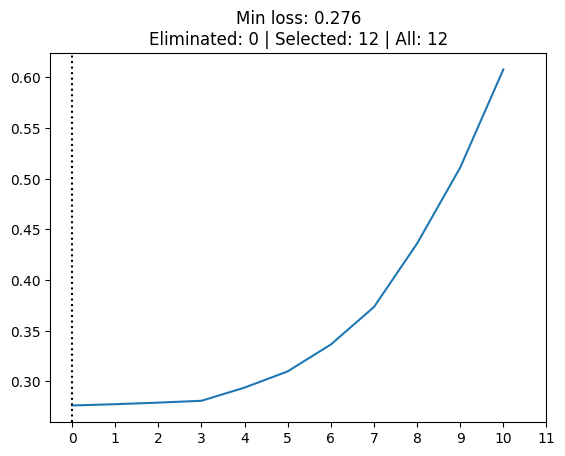

In [43]:
plot_loss_graph(select_features_response=select_features_response)
plt.show()
plt.close()

## Test

In [44]:
# Placeholder

# Define MonoforestAnalyzer

## Define

In [45]:
class MonoforestAnalyzer:
    def __init__(self, model: tstg.CatBoostModel) -> None:
        self.model = model

    def fit(self) -> "MonoforestAnalyzer":
        self.polynom_data: pd.DataFrame = self._get_polynomial_data()
        self.split_data: pd.DataFrame = self._get_split_data()
        self.joined_data: pd.DataFrame = self._join_data()
        self.aggregated_data: pd.DataFrame = self._aggregate_weights_by_feature_and_border()
        self.interaction_data: pd.DataFrame = self._filter_to_interactions()
        return self

    def get_formula_for_first_n_splits(self, n: int) -> str:
        def get_splits(data: pd.DataFrame) -> list[pd.DataFrame]:
            return tz.pipe(
                data.index.get_level_values(level=0).drop_duplicates(), tz.curried.map(lambda x: data.loc[x, :]), list
            )

        def format_split(data: pd.DataFrame) -> str:
            return tz.pipe(
                data.iterrows(),
                tz.curried.map(lambda x: "[%s %s %s]" % (x[0], x[1]["split_type"], x[1]["border"])),
                list,
                "".join,
                lambda x: "(%s) * %s" % (data["value"].iloc[0], x),
            )

        return tz.pipe(
            self.filter_to_first_n_splits(n=n),
            get_splits,
            tz.curried.map(format_split),
            list,
            lambda x: ["<Intercept>"] + x,
            "\n+ ".join,
        )

    def filter_to_first_n_splits(self, n: int) -> pd.DataFrame:
        splits: pd.Index = self.joined_data.index.get_level_values(level=0)
        first_n_splits: pd.Index = splits.to_series().drop_duplicates().head(n=n).index
        return self.joined_data.loc[splits.isin(values=first_n_splits), :]

    def filter_to_feature(self, feature: str) -> pd.DataFrame:
        return (
            self.joined_data.loc[lambda x: x.index.get_level_values(level=1).__eq__(feature), :]
            .swaplevel()
            .sort_values(by="border")
        )

    def _get_polynomial_data(self) -> pd.DataFrame:
        return (
            tz.pipe(self.model, cbmf.to_polynom, tz.curried.map(lambda x: x.__dict__), pd.DataFrame)
            .rename_axis(index="split_idx")
            .assign(**{"value": lambda x: x["value"].apply(func=lambda y: y[0])})
            .sort_values(by="weight", ascending=False)
        )

    def _get_split_data(self) -> pd.DataFrame:
        feature_names: dict[int, str] = dict(enumerate(iterable=self.model.feature_names_))
        return (
            self.polynom_data["splits"]
            .explode()
            .dropna()
            .apply(func=lambda x: x.__dict__)
            .apply(func=pd.Series)
            .assign(**{"feature": lambda x: x["feature_idx"].map(arg=feature_names)})
            .set_index(keys="feature", append=True)
        )

    def _join_data(self) -> pd.DataFrame:
        return self.split_data.drop(columns="feature_idx").join(
            other=self.polynom_data.drop(columns="splits"), how="left", validate="m:1"
        )

    def _aggregate_weights_by_feature_and_border(self) -> pd.DataFrame:
        return self.joined_data.reset_index().groupby(by=["feature", "border"])[["weight"]].sum().sort_index()

    def _filter_to_interactions(self) -> pd.DataFrame:
        def flag_interactions(data: pd.DataFrame) -> pd.Series:
            return data.groupby(level="split_idx").transform(func="size").gt(other=1)

        return self.joined_data.loc[flag_interactions, :]

## Demonstrate

In [46]:
# Fit model
model: snpe.Pipeline = get_model(depth=2, iterations=int(1e1), **get_model_args)[1:]
X_train_filtered: pd.DataFrame = X_train.select_dtypes(include="number").drop(columns=features_to_drop, errors="ignore")
model.fit(X=X_train_filtered, y=y_train)
# Fit analyzer
analyzer = MonoforestAnalyzer(model=model[-1]).fit()
# Get data attributes
for data_attr in ["polynom_data", "split_data", "joined_data", "aggregated_data", "interaction_data"]:  # type: str
    print("=" * int(8e1), data_attr, "-" * int(8e1), sep="\n")
    display(getattr(analyzer, data_attr))
# Get formulas and data for first N splits
for n in np.logspace(start=0, stop=3, num=4, base=2, dtype=int):  # type: int
    formula: str = analyzer.get_formula_for_first_n_splits(n=n)
    print("=" * int(8e1), "Formula for first %d splits" % n, "-" * int(8e1), formula, sep="\n")
display(analyzer.filter_to_first_n_splits(n=n))
# Get splits for given feature
analyzer.filter_to_feature(feature="age")

Learning rate set to 0.5
0:	test: 0.7239022	best: 0.7239022 (0)	total: 4.98ms	remaining: 44.9ms
1:	test: 0.7918585	best: 0.7918585 (1)	total: 9.68ms	remaining: 38.7ms
2:	test: 0.8048725	best: 0.8048725 (2)	total: 14.2ms	remaining: 33.2ms
3:	test: 0.8305985	best: 0.8305985 (3)	total: 18.6ms	remaining: 27.9ms
4:	test: 0.8414201	best: 0.8414201 (4)	total: 23ms	remaining: 23ms
5:	test: 0.8466567	best: 0.8466567 (5)	total: 27.5ms	remaining: 18.4ms
6:	test: 0.8487214	best: 0.8487214 (6)	total: 31.8ms	remaining: 13.6ms
7:	test: 0.8533540	best: 0.8533540 (7)	total: 36.1ms	remaining: 9.01ms
8:	test: 0.8538767	best: 0.8538767 (8)	total: 40.6ms	remaining: 4.51ms
9:	test: 0.8537377	best: 0.8538767 (8)	total: 44.9ms	remaining: 0us

bestTest = 0.853876713
bestIteration = 8

Shrink model to first 9 iterations.
polynom_data
--------------------------------------------------------------------------------


,splits,value,weight
split_idx,,,
2,[],-3.374951,31260.0
16,[[F1 > 8.5]],0.381376,27176.0
3,[[F4 > 38.5]],0.364993,23777.0
13,[[F0 > 27.5]],0.320029,23547.0
21,[[F0 > 30.5]],0.391528,21186.0
11,[[F1 > 9.5]],0.050063,17099.0
12,[[F0 > 36.5]],0.357700,16124.0
14,"[[F0 > 27.5], [F1 > 9.5]]",0.257243,13034.0
20,[[F1 > 11.5]],0.049959,8798.0


split_data
--------------------------------------------------------------------------------


feature_idx   split_type  border
split_idx feature                                         
16        education_num             1  TakeGreater     8.5
3         hours_per_week            4  TakeGreater    38.5
13        age                       0  TakeGreater    27.5
21        age                       0  TakeGreater    30.5
11        education_num             1  TakeGreater     9.5
12        age                       0  TakeGreater    36.5
14        age                       0  TakeGreater    27.5
          education_num             1  TakeGreater     9.5
20        education_num             1  TakeGreater    11.5
9         hours_per_week            4  TakeGreater    43.5
17        education_num             1  TakeGreater    12.5
22        age                       0  TakeGreater    30.5
          education_num             1  TakeGreater    11.5
0         age                       0  TakeGreater    36.5
          hours_per_week            4  TakeGreater    43.5
8         capital_gain              2  TakeGreater  4826.0
15        capital_gain              2  TakeGreater  5119.0
23        capital_gain              2  TakeGreater  4826.0
          hours_per_week            4  TakeGreater    38.5
10        capital_gain              2  TakeGreater  6505.5
7         capital_gain              2  TakeGreater  7073.5
18        capital_loss              3  TakeGreater  1820.5
5         capital_loss              3  TakeGreater  1846.0
4         education_num             1  TakeGreater    14.5
19        education_num             1  TakeGreater    12.5
          capital_gain              2  TakeGreater  5119.0
1         capital_loss              3  TakeGreater  1978.5
6         capital_gain              2  TakeGreater  6505.5
          capital_loss              3  TakeGreater  1846.0

joined_data
--------------------------------------------------------------------------------


split_type  border     value   weight
split_idx feature                                               
16        education_num   TakeGreater     8.5  0.381376  27176.0
3         hours_per_week  TakeGreater    38.5  0.364993  23777.0
13        age             TakeGreater    27.5  0.320029  23547.0
21        age             TakeGreater    30.5  0.391528  21186.0
11        education_num   TakeGreater     9.5  0.050063  17099.0
12        age             TakeGreater    36.5  0.357700  16124.0
14        age             TakeGreater    27.5  0.257243  13034.0
          education_num   TakeGreater     9.5  0.257243  13034.0
20        education_num   TakeGreater    11.5  0.049959   8798.0
9         hours_per_week  TakeGreater    43.5  0.407598   8762.0
17        education_num   TakeGreater    12.5  0.563341   7740.0
22        age             TakeGreater    30.5  0.361854   6738.0
          education_num   TakeGreater    11.5  0.361854   6738.0
0         age             TakeGreater    36.5 -0.017879   5212.0
          hours_per_week  TakeGreater    43.5 -0.017879   5212.0
8         capital_gain    TakeGreater  4826.0  0.624507   1587.0
15        capital_gain    TakeGreater  5119.0  1.523557   1492.0
23        capital_gain    TakeGreater  4826.0 -0.186223   1401.0
          hours_per_week  TakeGreater    38.5 -0.186223   1401.0
10        capital_gain    TakeGreater  6505.5 -0.454851   1354.0
7         capital_gain    TakeGreater  7073.5  1.914861   1323.0
18        capital_loss    TakeGreater  1820.5  0.778351    983.0
5         capital_loss    TakeGreater  1846.0  1.019055    977.0
4         education_num   TakeGreater    14.5  0.455628    916.0
19        education_num   TakeGreater    12.5 -0.420518    841.0
          capital_gain    TakeGreater  5119.0 -0.420518    841.0
1         capital_loss    TakeGreater  1978.5 -0.986522    350.0
6         capital_gain    TakeGreater  6505.5 -1.666687      0.0
          capital_loss    TakeGreater  1846.0 -1.666687      0.0

aggregated_data
--------------------------------------------------------------------------------


weight
feature        border         
age            27.5    36581.0
               30.5    27924.0
               36.5    21336.0
capital_gain   4826.0   2988.0
               5119.0   2333.0
               6505.5   1354.0
               7073.5   1323.0
capital_loss   1820.5    983.0
               1846.0    977.0
               1978.5    350.0
education_num  8.5     27176.0
               9.5     30133.0
               11.5    15536.0
               12.5     8581.0
               14.5      916.0
hours_per_week 38.5    25178.0
               43.5    13974.0

interaction_data
--------------------------------------------------------------------------------


split_type  border     value   weight
split_idx feature                                               
14        age             TakeGreater    27.5  0.257243  13034.0
          education_num   TakeGreater     9.5  0.257243  13034.0
22        age             TakeGreater    30.5  0.361854   6738.0
          education_num   TakeGreater    11.5  0.361854   6738.0
0         age             TakeGreater    36.5 -0.017879   5212.0
          hours_per_week  TakeGreater    43.5 -0.017879   5212.0
23        capital_gain    TakeGreater  4826.0 -0.186223   1401.0
          hours_per_week  TakeGreater    38.5 -0.186223   1401.0
19        education_num   TakeGreater    12.5 -0.420518    841.0
          capital_gain    TakeGreater  5119.0 -0.420518    841.0
6         capital_gain    TakeGreater  6505.5 -1.666687      0.0
          capital_loss    TakeGreater  1846.0 -1.666687      0.0

Formula for first 1 splits
--------------------------------------------------------------------------------
<Intercept>
+ (0.381375567947189) * [education_num TakeGreater 8.5]
Formula for first 2 splits
--------------------------------------------------------------------------------
<Intercept>
+ (0.381375567947189) * [education_num TakeGreater 8.5]
+ (0.36499251273431077) * [hours_per_week TakeGreater 38.5]
Formula for first 4 splits
--------------------------------------------------------------------------------
<Intercept>
+ (0.381375567947189) * [education_num TakeGreater 8.5]
+ (0.36499251273431077) * [hours_per_week TakeGreater 38.5]
+ (0.32002895754400984) * [age TakeGreater 27.5]
+ (0.3915283462874252) * [age TakeGreater 30.5]
Formula for first 8 splits
--------------------------------------------------------------------------------
<Intercept>
+ (0.381375567947189) * [education_num TakeGreater 8.5]
+ (0.36499251273431077) * [hours_per_week TakeGreater 38.5]
+ (0.32002895754400

split_type  border     value   weight
split_idx feature                                               
16        education_num   TakeGreater     8.5  0.381376  27176.0
3         hours_per_week  TakeGreater    38.5  0.364993  23777.0
13        age             TakeGreater    27.5  0.320029  23547.0
21        age             TakeGreater    30.5  0.391528  21186.0
11        education_num   TakeGreater     9.5  0.050063  17099.0
12        age             TakeGreater    36.5  0.357700  16124.0
14        age             TakeGreater    27.5  0.257243  13034.0
          education_num   TakeGreater     9.5  0.257243  13034.0
20        education_num   TakeGreater    11.5  0.049959   8798.0

split_type  border     value   weight
feature split_idx                                        
age     13         TakeGreater    27.5  0.320029  23547.0
        14         TakeGreater    27.5  0.257243  13034.0
        21         TakeGreater    30.5  0.391528  21186.0
        22         TakeGreater    30.5  0.361854   6738.0
        12         TakeGreater    36.5  0.357700  16124.0
        0          TakeGreater    36.5 -0.017879   5212.0

## Test

In [47]:
# Placeholder

# Define ValidationChangeCallback

## Define

In [48]:
class ValidationChangeCallback:
    def __init__(self, metric: str, threshold: float = 1e-4) -> None:
        self.metric, self.threshold = metric, threshold

    def after_iteration(self, info: typing.Any) -> bool:
        try:
            metric_before, metric_after = map(lambda x: info.metrics["validation"][self.metric][x], [-2, -1])  # type: tuple[float, float]
            absolute_change: float = abs(metric_after - metric_before)
            should_continue: bool = absolute_change > self.threshold
        except Exception as exception:
            should_continue: bool = True
        return should_continue

## Demonstrate

In [49]:
model: snpe.Pipeline = get_model(iterations=int(1e3), verbose=int(1e2), **get_model_args)
callback_ags: dict[str, float | str] = dict(metric="Logloss", threshold=1e-4)
fit_args: dict[str, list] = dict(catboostclassifier__callbacks=[ValidationChangeCallback(**callback_ags)])
model.fit(X=X_train, y=y_train, **fit_args)
evals_result: pd.DataFrame = get_evals_result(model=model[-1])
assign_args: dict[str, typing.Callable] = {
    "absolute_change": lambda x: x["validation"].diff().abs(),
    "is_below_threshold": lambda x: x["absolute_change"].lt(other=callback_ags["threshold"]),
}
evals_result[callback_ags["metric"]][["validation"]].assign(**assign_args)

Learning rate set to 0.07416
0:	test: 0.8874803	best: 0.8874803 (0)	total: 64.3ms	remaining: 1m 4s

bestTest = 0.9228502359
bestIteration = 62

Shrink model to first 63 iterations.


,validation,absolute_change,is_below_threshold
0,0.615825,NaN,False
1,0.555403,0.060423,False
2,0.512852,0.042551,False
3,0.477972,0.034880,False
4,0.445106,0.032866,False
...,...,...,...
59,0.290999,0.000109,False
60,0.290797,0.000202,False
61,0.290520,0.000277,False
62,0.290411,0.000108,False


## Test

In [50]:
# Placeholder

# Define ValidationDifferenceCallback

## Define

In [51]:
class ValidationDifferenceCallback:
    def __init__(self, metric: str, threshold: float = 1e-2) -> None:
        self.metric, self.threshold = metric, threshold

    def after_iteration(self, info: typing.Any) -> bool:
        learn_metric: float = info.metrics["learn"][self.metric][-1]
        validation_metric: float = info.metrics["validation"][self.metric][-1]
        absolute_difference: float = abs(validation_metric - learn_metric)
        should_continue: bool = absolute_difference < self.threshold
        return should_continue

## Demonstrate

In [52]:
model: snpe.Pipeline = get_model(iterations=int(1e3), verbose=int(1e2), **get_model_args)
callback_ags["threshold"] = 1e-2
fit_args: dict[str, list] = dict(catboostclassifier__callbacks=[ValidationDifferenceCallback(**callback_ags)])
model.fit(X=X_train, y=y_train, **fit_args)
evals_result: pd.DataFrame = get_evals_result(model=model[-1])
assign_args: dict[str, typing.Callable] = {
    "absolute_difference": lambda x: x.diff(axis=1).iloc[:, -1],
    "is_above_threshold": lambda x: x["absolute_difference"].gt(other=callback_ags["threshold"]),
}
evals_result[callback_ags["metric"]].assign(**assign_args)

Learning rate set to 0.07416
0:	test: 0.8874803	best: 0.8874803 (0)	total: 58.6ms	remaining: 58.5s
100:	test: 0.9255316	best: 0.9255316 (100)	total: 6.5s	remaining: 57.9s

bestTest = 0.9273203114
bestIteration = 163

Shrink model to first 164 iterations.


,learn,validation,absolute_difference,is_above_threshold
0,0.616348,0.615825,-0.000522,False
1,0.556685,0.555403,-0.001282,False
2,0.514767,0.512852,-0.001915,False
3,0.480156,0.477972,-0.002185,False
4,0.446783,0.445106,-0.001677,False
...,...,...,...,...
164,0.270576,0.280458,0.009882,False
165,0.270573,0.280463,0.009890,False
166,0.270569,0.280464,0.009896,False
167,0.270525,0.280440,0.009915,False


## Test

In [53]:
# Placeholder

# Write module

## Write

In [54]:
module_path: str = "src/tools/%s.py" % module

In [55]:
%%file $module_path

import typing

import catboost as cb
import pandas as pd
import toolz as tz
from catboost import monoforest as cbmf
from matplotlib import pyplot as plt
from tools import typing as tstg

dict_feature_args: list[str] = ["monotone_constraints"]
list_feature_args: list[str] = ["cat_features", "embedding_features", "text_features"]

class CatBoostAnalyzer:
    def __init__(self, model: tstg.CatBoostModel, metrics: list) -> None:
        self.model, self.metrics = model, metrics

    def fit(self, X: pd.DataFrame, y: pd.Series) -> "CatBoostAnalyzer":
        pool: cb.Pool = get_pool(X=X, y=y, model=self.model)
        self.eval_metrics: pd.DataFrame = get_eval_metrics(model=self.model, pool=pool, metrics=self.metrics)
        self.feature_importances: pd.DataFrame = get_feature_importances(model=self.model, pool=pool)
        if self.model.get_all_params().get("depth") > 1:
            self.feature_interactions: pd.DataFrame = get_feature_interactions(model=self.model, pool=pool)
        return self

    def plot_eval_metrics(self, **kwargs) -> plt.Figure:
        self.eval_metrics.plot(subplots=True, **tz.keyfilter(predicate=lambda x: x not in ["subplots"], d=kwargs))
        return plt.gcf()

    def plot_feature_importances(self, bbox: list | tuple = (1.2, 0, 4e-1, 1), **kwargs) -> plt.Figure:
        filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["subplots"], d=kwargs)
        axes: tstg.Axes = self.feature_importances.plot(subplots=True, **filtered_kwargs)
        for ax in axes.flat:  # type: plt.Axes
            ax.axhline(c="k", ls=":")
            ax.set(xticks=[])
            column: str = ax.get_legend().get_texts()[0]._text
            data: pd.Series = self.feature_importances[column].describe().round(decimals=3)
            pd.plotting.table(ax=ax, data=data, bbox=bbox)
        return plt.gcf()

    def plot_top_feature_importances(self, n: int = int(1e1), **kwargs) -> tstg.Axes:
        plot_args = dict(kind="barh", subplots=True, layout=(1, -1), sharex=False, sharey=True, legend=False)
        filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in plot_args, d=kwargs)
        return (
            self.feature_importances.nlargest(n=n, columns="LossFunctionChange")
            .iloc[::-1, :]
            .plot(**plot_args, **filtered_kwargs)
        )

    def plot_feature_interactions(self, bbox: list | tuple = (1.2, 0, 2e-1, 1), **kwargs) -> plt.Axes:
        feature_interactions: pd.Series = self.feature_interactions["interaction_strength"]
        ax: plt.Axes = feature_interactions.plot(**kwargs)
        ax.axhline(c="k", ls=":")
        ax.set(xticks=[])
        data: pd.Series = feature_interactions.describe().round(decimals=3)
        pd.plotting.table(ax=ax, data=data, bbox=bbox)
        return ax

    def plot_top_feature_interactions(self, n: int = int(1e1), **kwargs) -> plt.Axes:
        filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["kind"], d=kwargs)
        return self.feature_interactions.squeeze().nlargest(n=n).iloc[::-1].plot(kind="barh", **filtered_kwargs)


class CatBoostClassifier(cb.CatBoostClassifier):
    def fit(self, X: pd.DataFrame, y: pd.Series, **kwargs) -> "CatBoostClassifier":
        self._update_feature_params(X=X)
        return super().fit(X=X, y=y, **kwargs)

    def select_features(
        self, X: pd.DataFrame, y: pd.Series, features_not_for_select: list[str] | None = None, **kwargs
    ) -> dict[str, typing.Any]:
        self._update_feature_params(X=X)
        if "features_for_select" not in kwargs:
            kwargs.update(features_for_select=X.columns.difference(other=features_not_for_select or []).tolist())
        return super().select_features(X=X, y=y, **kwargs)

    def _update_feature_params(self, X: pd.DataFrame) -> None:
        params: dict[str, typing.Any] = self.get_params()
        params = update_feature_params(params=params, X=X)
        self.set_params(**params)


class CatBoostRegressor(cb.CatBoostRegressor):
    def fit(self, X: pd.DataFrame, y: pd.Series, **kwargs) -> "CatBoostRegressor":
        self._update_feature_params(X=X)
        return super().fit(X=X, y=y, **kwargs)

    def select_features(
        self, X: pd.DataFrame, y: pd.Series, features_not_for_select: list[str] | None = None, **kwargs
    ) -> dict[str, typing.Any]:
        self._update_feature_params(X=X)
        if "features_for_select" not in kwargs:
            kwargs.update(features_for_select=X.columns.difference(other=features_not_for_select or []).tolist())
        return super().select_features(X=X, y=y, **kwargs)

    def _update_feature_params(self, X: pd.DataFrame) -> None:
        params: dict[str, typing.Any] = self.get_params()
        params = update_feature_params(params=params, X=X)
        self.set_params(**params)


class MonoforestAnalyzer:
    def __init__(self, model: tstg.CatBoostModel) -> None:
        self.model = model

    def fit(self) -> "MonoforestAnalyzer":
        self.polynom_data: pd.DataFrame = self._get_polynomial_data()
        self.split_data: pd.DataFrame = self._get_split_data()
        self.joined_data: pd.DataFrame = self._join_data()
        self.aggregated_data: pd.DataFrame = self._aggregate_weights_by_feature_and_border()
        self.interaction_data: pd.DataFrame = self._filter_to_interactions()
        return self

    def get_formula_for_first_n_splits(self, n: int) -> str:
        def get_splits(data: pd.DataFrame) -> list[pd.DataFrame]:
            return tz.pipe(
                data.index.get_level_values(level=0).drop_duplicates(), tz.curried.map(lambda x: data.loc[x, :]), list
            )

        def format_split(data: pd.DataFrame) -> str:
            return tz.pipe(
                data.iterrows(),
                tz.curried.map(lambda x: "[%s %s %s]" % (x[0], x[1]["split_type"], x[1]["border"])),
                list,
                "".join,
                lambda x: "(%s) * %s" % (data["value"].iloc[0], x),
            )

        return tz.pipe(
            self.filter_to_first_n_splits(n=n),
            get_splits,
            tz.curried.map(format_split),
            list,
            lambda x: ["<Intercept>"] + x,
            "\n+ ".join,
        )

    def filter_to_first_n_splits(self, n: int) -> pd.DataFrame:
        splits: pd.Index = self.joined_data.index.get_level_values(level=0)
        first_n_splits: pd.Index = splits.to_series().drop_duplicates().head(n=n).index
        return self.joined_data.loc[splits.isin(values=first_n_splits), :]

    def filter_to_feature(self, feature: str) -> pd.DataFrame:
        return (
            self.joined_data.loc[lambda x: x.index.get_level_values(level=1).__eq__(feature), :]
            .swaplevel()
            .sort_values(by="border")
        )

    def _get_polynomial_data(self) -> pd.DataFrame:
        return (
            tz.pipe(self.model, cbmf.to_polynom, tz.curried.map(lambda x: x.__dict__), pd.DataFrame)
            .rename_axis(index="split_idx")
            .assign(**{"value": lambda x: x["value"].apply(func=lambda y: y[0])})
            .sort_values(by="weight", ascending=False)
        )

    def _get_split_data(self) -> pd.DataFrame:
        feature_names: dict[int, str] = dict(enumerate(iterable=self.model.feature_names_))
        return (
            self.polynom_data["splits"]
            .explode()
            .dropna()
            .apply(func=lambda x: x.__dict__)
            .apply(func=pd.Series)
            .assign(**{"feature": lambda x: x["feature_idx"].map(arg=feature_names)})
            .set_index(keys="feature", append=True)
        )

    def _join_data(self) -> pd.DataFrame:
        return self.split_data.drop(columns="feature_idx").join(
            other=self.polynom_data.drop(columns="splits"), how="left", validate="m:1"
        )

    def _aggregate_weights_by_feature_and_border(self) -> pd.DataFrame:
        return self.joined_data.reset_index().groupby(by=["feature", "border"])[["weight"]].sum().sort_index()

    def _filter_to_interactions(self) -> pd.DataFrame:
        def flag_interactions(data: pd.DataFrame) -> pd.Series:
            return data.groupby(level="split_idx").transform(func="size").gt(other=1)

        return self.joined_data.loc[flag_interactions, :]


class ValidationChangeCallback:
    def __init__(self, metric: str, threshold: float = 1e-4) -> None:
        self.metric, self.threshold = metric, threshold

    def after_iteration(self, info: typing.Any) -> bool:
        try:
            metric_before, metric_after = map(lambda x: info.metrics["validation"][self.metric][x], [-2, -1])  # type: tuple[float, float]
            absolute_change: float = abs(metric_after - metric_before)
            should_continue: bool = absolute_change > self.threshold
        except Exception as exception:
            should_continue: bool = True
        return should_continue


class ValidationDifferenceCallback:
    def __init__(self, metric: str, threshold: float = 1e-2) -> None:
        self.metric, self.threshold = metric, threshold

    def after_iteration(self, info: typing.Any) -> bool:
        learn_metric: float = info.metrics["learn"][self.metric][-1]
        validation_metric: float = info.metrics["validation"][self.metric][-1]
        absolute_difference: float = abs(validation_metric - learn_metric)
        should_continue: bool = absolute_difference < self.threshold
        return should_continue


def filter_select_features_response(
    parse_response: tuple[pd.Series, pd.Index, pd.Index],
) -> tuple[float, pd.Index, pd.Index]:
    loss_graph, eliminated_features, selected_features = parse_response
    min_loss: float = loss_graph.min()
    min_loss_feature: str = loss_graph.idxmin()
    optimal_eliminated_features: pd.Index = loss_graph.loc[:min_loss_feature].index[:-1]
    optimal_selected_features: pd.Index = eliminated_features.difference(other=optimal_eliminated_features).union(
        other=selected_features
    )
    return min_loss, optimal_eliminated_features, optimal_selected_features


def get_eval_metrics(model: tstg.CatBoostModel, pool: cb.Pool, metrics: list) -> pd.DataFrame:
    return pd.DataFrame(data=model.eval_metrics(data=pool, metrics=metrics))


def get_evals_result(model: tstg.CatBoostModel) -> pd.DataFrame:
    return pd.DataFrame(data=model.evals_result_).stack().apply(func=pd.Series).T


def get_feature_importances(model: tstg.CatBoostModel, pool: cb.Pool) -> pd.DataFrame:
    def get_feature_importances(importance_type: str) -> pd.Series:
        return pd.Series(
            data=model.get_feature_importance(data=pool, type=importance_type),
            index=model.feature_names_,
            name=importance_type,
        )

    return tz.pipe(
        ["PredictionValuesChange", "LossFunctionChange"],
        tz.curried.map(get_feature_importances),
        tz.partial(pd.concat, axis=1),
    ).sort_values(by="LossFunctionChange", ascending=False)


def get_feature_interactions(model: tstg.CatBoostModel, pool: cb.Pool) -> pd.DataFrame:
    columns: list[str] = ["first_feature", "second_feature", "interaction_strength"]
    return (
        pd.DataFrame(data=model.get_feature_importance(data=pool, type="Interaction"), columns=columns)
        .astype(dtype=dict(map(lambda x: [x, int], columns[:2])))
        .apply(func=lambda x: x.map(arg=dict(enumerate(iterable=model.feature_names_))) if x.name in columns[:2] else x)
        .set_index(keys=columns[:2])
    )


def get_pool(X: pd.DataFrame, y: pd.Series, model: tstg.CatBoostModel) -> cb.Pool:
    return tz.pipe(
        model.get_params(),
        tz.curried.keyfilter(lambda x: x in list_feature_args),
        lambda x: cb.Pool(data=X, label=y, **x),
    )


def parse_select_features_response(
    select_features_response: dict[str, typing.Any],
) -> tuple[pd.Series, pd.Index, pd.Index]:
    loss_graph: pd.Series = pd.Series(
        data=select_features_response["loss_graph"]["loss_values"][1:],
        index=select_features_response["eliminated_features_names"],
        name="loss",
    )
    eliminated_features: pd.Index = loss_graph.index
    selected_features: pd.Index = pd.Index(data=select_features_response["selected_features_names"])
    return loss_graph, eliminated_features, selected_features


def plot_evals_result(evals_result: pd.DataFrame, **kwargs) -> plt.Figure:
    metrics: pd.Index = evals_result.columns.get_level_values(level=0).drop_duplicates()
    fig, axes = plt.subplots(nrows=metrics.shape[0], sharex=True, squeeze=False)  # tstg.FigAxes
    for metric, ax in zip(metrics, axes.flat):  # type: tuple[str, tstg.Axes]
        plot_args = dict(title=metric, ax=ax)
        filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in plot_args, d=kwargs)
        evals_result[metric].plot(**plot_args, **filtered_kwargs)
    fig.tight_layout()
    return fig


def plot_loss_graph(select_features_response: dict[str, typing.Any], **kwargs) -> plt.Axes:
    # Parse
    parse_response = parse_select_features_response(select_features_response=select_features_response)  # type: tuple[pd.Series, pd.Index, pd.Index]
    loss_graph, eliminated_features, selected_features = parse_response
    # Filter
    filter_response = filter_select_features_response(parse_response=parse_response)  # type: tuple[float, pd.Index, pd.Index]
    min_loss, optimal_eliminated_features, optimal_selected_features = filter_response
    # Count
    all_features: pd.Index = optimal_selected_features.union(optimal_eliminated_features)
    fn: typing.Callable = lambda x: x.shape[0]
    feature_counts: list[int] = list(map(fn, [optimal_eliminated_features, optimal_selected_features, all_features]))
    all_feature_count: int = feature_counts[-1]
    optimal_eliminated_feature_count: int = feature_counts[0]
    # Plot
    title: str = "Min loss: %.3f\nEliminated: %d | Selected: %d | All: %d" % (min_loss, *feature_counts)
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["xticks", "title"], d=kwargs)
    ax: plt.Axes = loss_graph.plot(xticks=range(all_feature_count), title=title, **filtered_kwargs)
    ax.axvline(x=optimal_eliminated_feature_count, c="k", ls=":")
    ax.set(xticklabels=range(all_feature_count))
    return ax


def update_feature_params(params: dict[str, typing.Any], X: pd.DataFrame) -> dict[str, typing.Any]:
    for arg in dict_feature_args:
        dict_param: dict = tz.keyfilter(predicate=lambda x: x in X, d=params.get(arg, {}))
        params.update(**{arg: dict_param})
    for arg in list_feature_args:
        list_param: list = X.columns.intersection(other=params.get(arg, [])).tolist()
        params.update(**{arg: list_param})
    return params

Writing src/tools/catboost.py


## Format

In [56]:
!ruff format $module_path

1 file reformatted


## Check with ruff

In [57]:
!ruff check $module_path

ANN003 Missing type annotation for `**kwargs`
  --> src\tools\catboost.py:26:33
   |
24 |         return self
25 |
26 |     def plot_eval_metrics(self, **kwargs) -> plt.Figure:
   |                                 ^^^^^^^^
27 |         self.eval_metrics.plot(subplots=True, **tz.keyfilter(predicate=lambda x: x not in ["subplots"], d=kwargs))
28 |         return plt.gcf()
   |

ANN003 Missing type annotation for `**kwargs`
  --> src\tools\catboost.py:30:80
   |
28 |         return plt.gcf()
29 |
30 |     def plot_feature_importances(self, bbox: list | tuple = (1.2, 0, 4e-1, 1), **kwargs) -> plt.Figure:
   |                                                                                ^^^^^^^^
31 |         filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["subplots"], d=kwargs)
32 |         axes: tstg.Axes = self.feature_importances.plot(subplots=True, **filtered_kwargs)
   |

ANN003 Missing type annotation for `**kwargs`
  --> src\tools\catboost.py:41:6

## Check with ty

In [58]:
!ty check $module_path

error[invalid-method-override]: Invalid override of method `fit`
    --> src\tools\catboost.py:65:9
     |
  64 |   class CatBoostClassifier(cb.CatBoostClassifier):
  65 |       def fit(self, X: pd.DataFrame, y: pd.Series, **kwargs) -> "CatBoostClassifier":
     |           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^ Definition is incompatible with `catboost.core.CatBoostClassifier.fit`
  66 |           self._update_feature_params(X=X)
  67 |           return super().fit(X=X, y=y, **kwargs)
     |
    ::: env\Lib\site-packages\catboost\core.py:5435:9
     |
5433 |           super(CatBoostClassifier, self).__init__(params)
5434 |
5435 |       def fit(self, X, y=None, cat_features=None, text_features=None, embedding_features=None, graph=None, sample_weight=None, baselinâ€¦
     |  _________-
5436 | |             eval_set=None, verbose=None, logging_level=None, plot=False, plot_file=None, column_description=None,
5437 | |             verbose_eval=None, metri